# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

### 0. importy

In [365]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    recall_score,
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

### 1. EDA - analiza

In [366]:
from ucimlrepo import fetch_ucirepo

# Pobranie zbioru Obesity (UCI ID: 544)
obesity = fetch_ucirepo(id=544)

X = obesity.data.features
y = obesity.data.targets.squeeze()

print("Kształt X:", X.shape)
print("Kształt y:", y.shape)
print("\nKlasy:", y.unique())
print("\nPrzykładowe wiersze:")
X.head()

Kształt X: (2111, 16)
Kształt y: (2111,)

Klasy: <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

Przykładowe wiersze:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


In [367]:
# stworzenie df
df = X.copy()
df["NObeyesdad"] = y

# przeglad ogolny
print("=== Informacje o zbiorze ===")
df.info()
print("\n=== Statystyki opisowe (numeryczne) ===")
df.describe().round(2)

=== Informacje o zbiorze ===
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF             

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


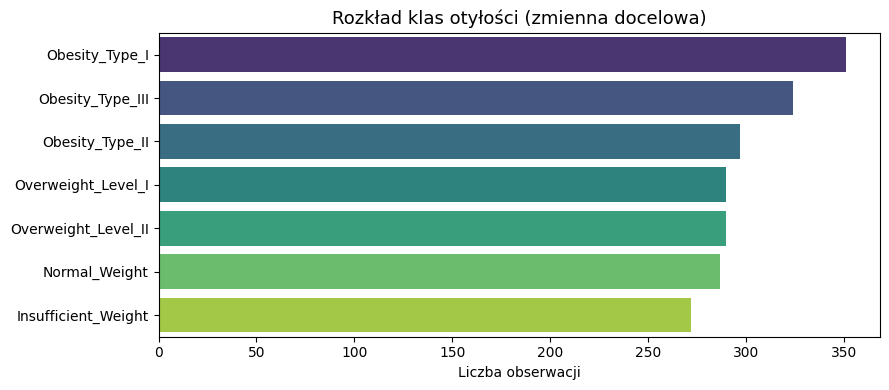

In [368]:
# rozklad zmiennej docelowej
fig, ax = plt.subplots(figsize=(9, 4))
order = df["NObeyesdad"].value_counts().index

sns.countplot(data=df, y="NObeyesdad", order=order, palette="viridis", ax=ax)
ax.set_title("Rozkład klas otyłości (zmienna docelowa)", fontsize=13)
ax.set_xlabel("Liczba obserwacji")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

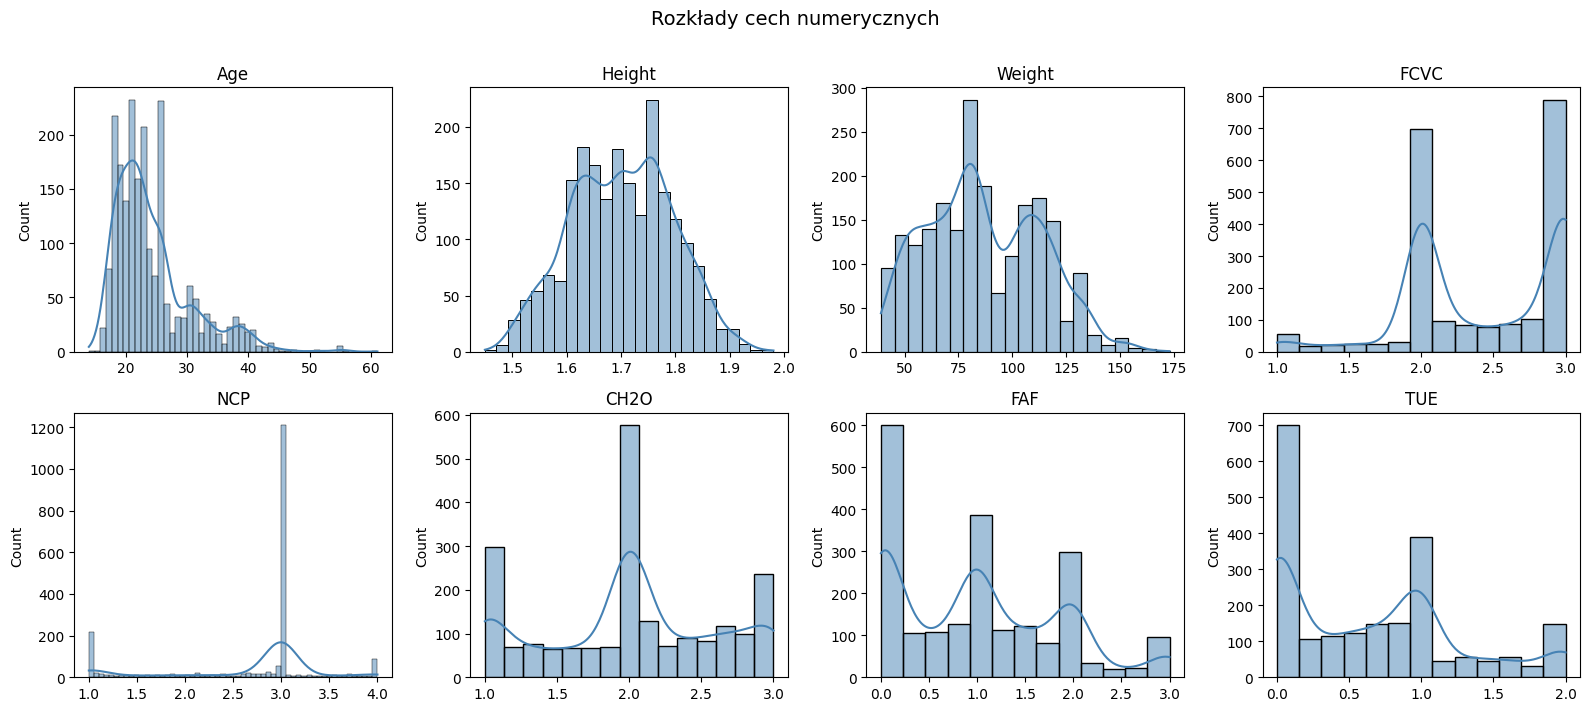

In [369]:
# rozklad cech numerycznych
num_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Rozkłady cech numerycznych", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

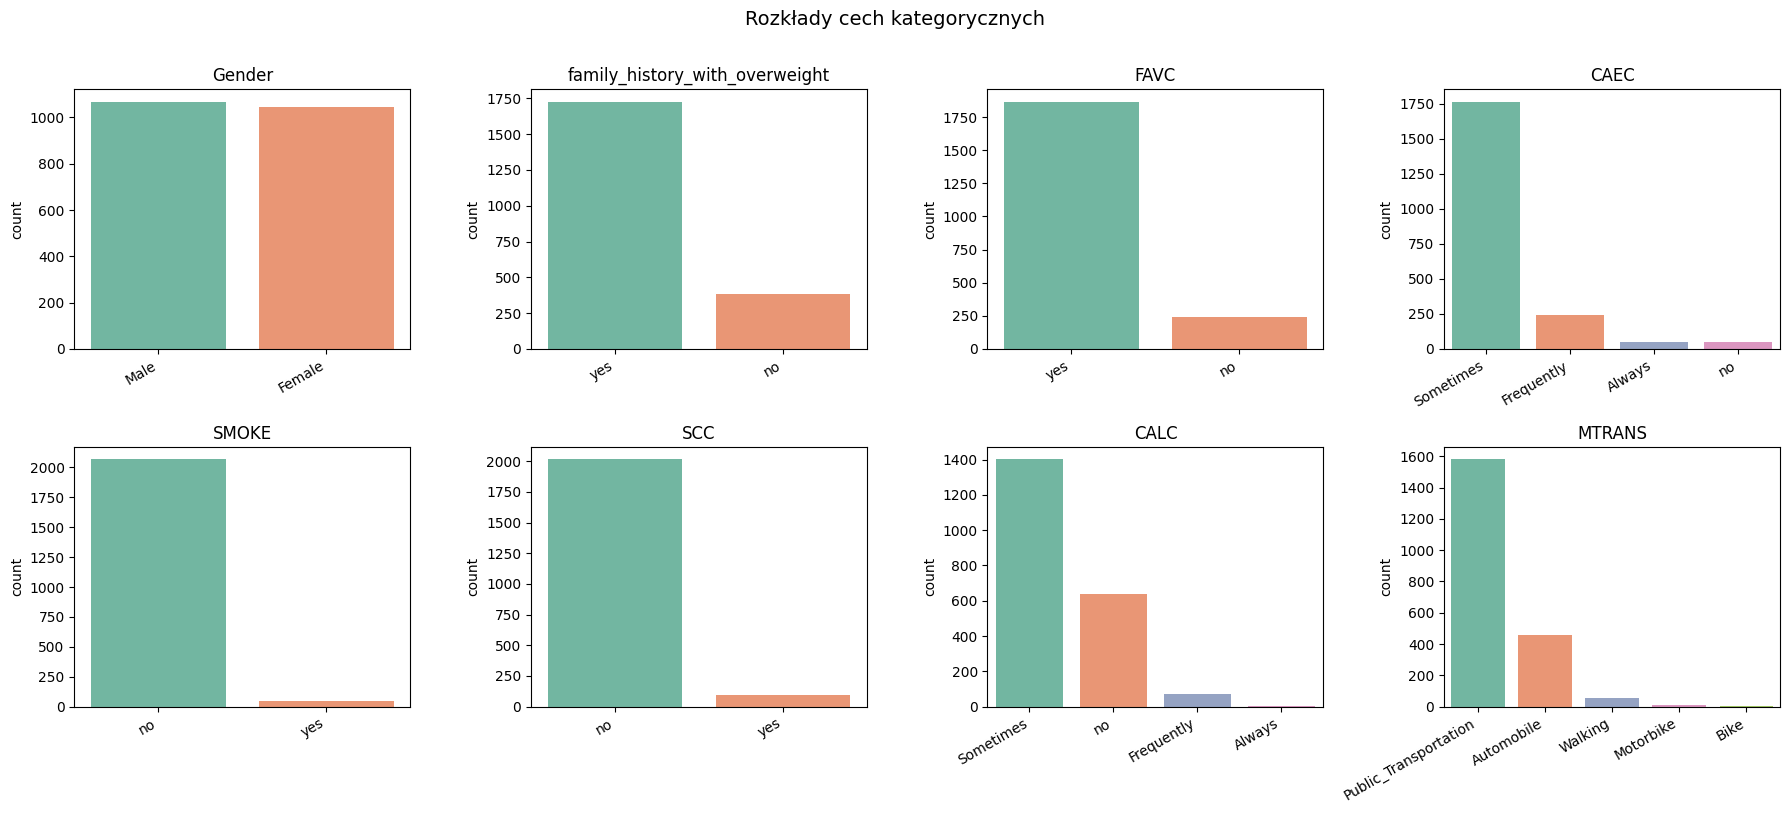

In [370]:
# cechy kategoryczne
cat_cols = [
    "Gender", "family_history_with_overweight", "FAVC",
    "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="Set2")
    ax.set_title(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_xlabel("")
plt.suptitle("Rozkłady cech kategorycznych", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

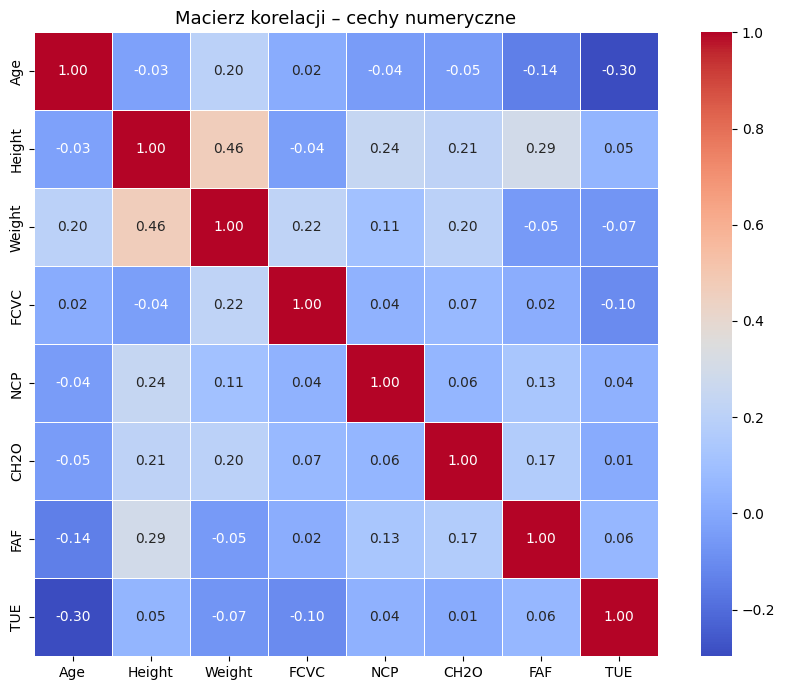

In [371]:
# macierz korelacji
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Macierz korelacji – cechy numeryczne", fontsize=13)
plt.tight_layout()
plt.show()

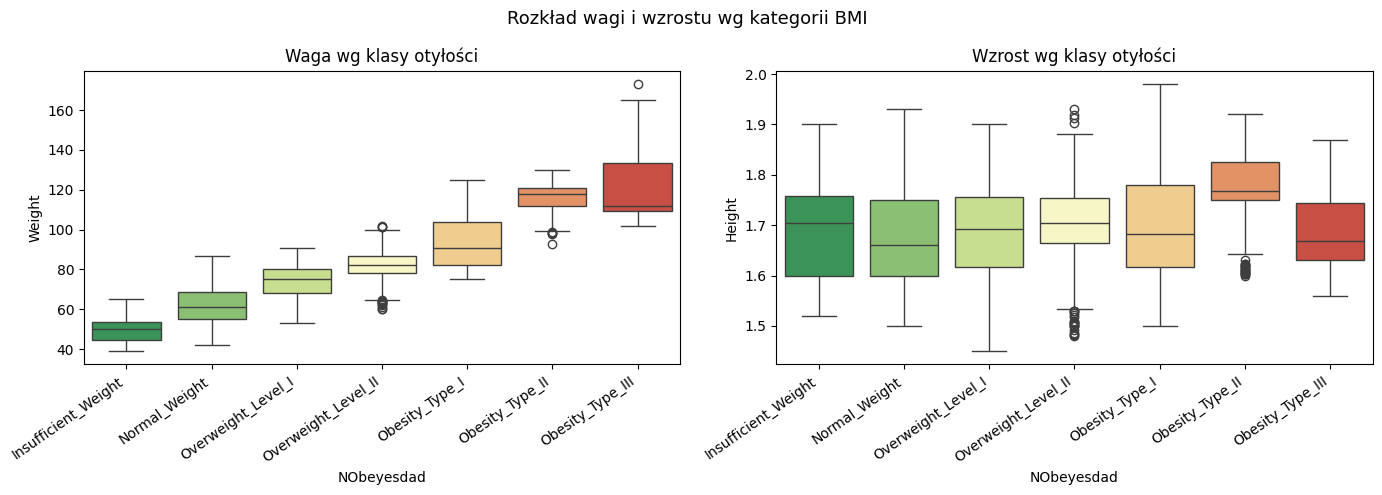

In [372]:
# waga i wzrost wg klasy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I", "Overweight_Level_II",
    "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"
]

sns.boxplot(data=df, x="NObeyesdad", y="Weight", order=order,
            palette="RdYlGn_r", ax=axes[0])
axes[0].set_title("Waga wg klasy otyłości")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")

sns.boxplot(data=df, x="NObeyesdad", y="Height", order=order,
            palette="RdYlGn_r", ax=axes[1])
axes[1].set_title("Wzrost wg klasy otyłości")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right")

plt.suptitle("Rozkład wagi i wzrostu wg kategorii BMI", fontsize=13)
plt.tight_layout()
plt.show()

### 2. Preprocessing i podzial danych

In [373]:
# Kolumny binarne (yes/no)
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

# Kolumny
caec_order  = ["no", "Sometimes", "Frequently", "Always"]
calc_order  = ["no", "Sometimes", "Frequently", "Always"]

# Kolumny nominalne (OHE)
nominal_cols = ["Gender", "MTRANS"]

# Kolumny numeryczne (bez zmian dla drzew; scaler dla LR)
num_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

# Preprocessor BEZ skalowania (dla drzew/ensemble)
preprocessor_tree = ColumnTransformer(transformers=[
    ("num",    "passthrough",                                              num_cols),
    ("bin",    OrdinalEncoder(),                                           binary_cols),
    ("caec",   OrdinalEncoder(categories=[caec_order]),                   ["CAEC"]),
    ("calc",   OrdinalEncoder(categories=[calc_order]),                   ["CALC"]),
    ("nom",    OneHotEncoder(drop="first", sparse_output=False),          nominal_cols),
], remainder="drop")

# Preprocessor ZE skalowaniem (dla regresji logistycznej)
preprocessor_lr = ColumnTransformer(transformers=[
    ("num",    StandardScaler(),                                           num_cols),
    ("bin",    OrdinalEncoder(),                                           binary_cols),
    ("caec",   OrdinalEncoder(categories=[caec_order]),                   ["CAEC"]),
    ("calc",   OrdinalEncoder(categories=[calc_order]),                   ["CALC"]),
    ("nom",    OneHotEncoder(drop="first", sparse_output=False),          nominal_cols),
], remainder="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek")

Zbiór treningowy: 1477 próbek
Zbiór testowy:    634 próbek


In [374]:
results = {}  # słownik do przechowywania wyników wszystkich modeli

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test, cv=5):
    """Trenuje pipeline, mierzy czas predykcji, accuracy, F1 macro i confidence."""
    pipeline.fit(X_train, y_train)

    # Czas predykcji (średnia z 50 powtórzeń)
    times = []
    for _ in range(50):
        t0 = time.perf_counter()
        pipeline.predict(X_test)
        times.append(time.perf_counter() - t0)
    inference_ms = np.mean(times) * 1000  # ms

    y_pred = pipeline.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average="macro")

    # Confidence (tylko jeśli model obsługuje predict_proba)
    if hasattr(pipeline, "predict_proba"):
        proba      = pipeline.predict_proba(X_test)
        confidence = float(np.mean(np.max(proba, axis=1)))
    else:
        confidence = float("nan")

    # Cross-validation accuracy
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")

    results[name] = {
        "Accuracy":       round(acc, 4),
        "F1 macro":       round(f1, 4),
        "CV Acc (mean)":  round(cv_scores.mean(), 4),
        "CV Acc (std)":   round(cv_scores.std(), 4),
        "Confidence":     round(confidence, 4),
        "Inference (ms)": round(inference_ms, 3),
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy       : {acc*100:.2f}%")
    print(f"  F1 macro       : {f1*100:.2f}%")
    print(f"  CV Acc         : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"  Confidence     : {confidence*100:.2f}%")
    print(f"  Inference time : {inference_ms:.3f} ms")

    return pipeline

### 3. Modele bazowe

In [375]:
# 1. Drzewo decyzyjne (bazowe)
dt_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  DecisionTreeClassifier(random_state=42))
])
dt_pipe = evaluate_model("Drzewo decyzyjne (baseline)", dt_pipe,
                          X_train, X_test, y_train, y_test)

# 2. Regresja logistyczna (bazowa)
lr_pipe = Pipeline([
    ("prep", preprocessor_lr),
    ("clf",  LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe = evaluate_model("Regresja logistyczna (baseline)", lr_pipe,
                          X_train, X_test, y_train, y_test)


  Drzewo decyzyjne (baseline)
  Accuracy       : 90.06%
  F1 macro       : 89.92%
  CV Acc         : 93.43% ± 1.20%
  Confidence     : 100.00%
  Inference time : 1.860 ms

  Regresja logistyczna (baseline)
  Accuracy       : 86.59%
  F1 macro       : 86.22%
  CV Acc         : 86.80% ± 1.29%
  Confidence     : 73.40%
  Inference time : 1.920 ms


### 4. Bagging

In [376]:
# 3. Bagging: płytkie drzewo
bag_shallow_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=50, bootstrap=True, bootstrap_features=False, random_state=42
    ))
])
bag_shallow_pipe = evaluate_model("Bagging – płytkie drzewo (depth=3, n=50)",
                                   bag_shallow_pipe, X_train, X_test, y_train, y_test)

# 4. Bagging: głębokie drzewo
bag_deep_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
        n_estimators=50, bootstrap=True, bootstrap_features=False, random_state=42
    ))
])
bag_deep_pipe = evaluate_model("Bagging – głębokie drzewo (depth=None, n=50)",
                                bag_deep_pipe, X_train, X_test, y_train, y_test)

# 5. Bagging: regresja logistyczna
bag_lr_pipe = Pipeline([
    ("prep", preprocessor_lr),
    ("clf",  BaggingClassifier(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        n_estimators=20, bootstrap=True, bootstrap_features=True, random_state=42
    ))
])
bag_lr_pipe = evaluate_model("Bagging – regresja logistyczna (n=20, boot_feat=True)",
                              bag_lr_pipe, X_train, X_test, y_train, y_test)


  Bagging – płytkie drzewo (depth=3, n=50)
  Accuracy       : 69.56%
  F1 macro       : 67.34%
  CV Acc         : 70.48% ± 5.15%
  Confidence     : 61.79%
  Inference time : 3.974 ms

  Bagging – głębokie drzewo (depth=None, n=50)
  Accuracy       : 94.16%
  F1 macro       : 94.17%
  CV Acc         : 94.86% ± 1.39%
  Confidence     : 92.21%
  Inference time : 4.517 ms

  Bagging – regresja logistyczna (n=20, boot_feat=True)
  Accuracy       : 86.12%
  F1 macro       : 85.59%
  CV Acc         : 86.53% ± 1.25%
  Confidence     : 60.12%
  Inference time : 3.456 ms


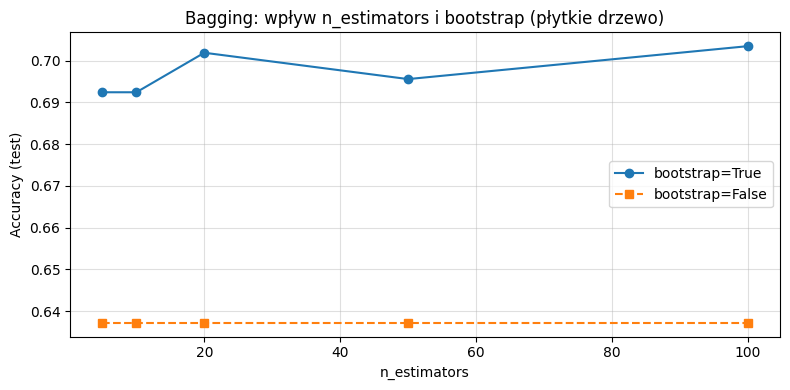

In [377]:
# Wpływ parametrów Baggingu (wykres)
n_range     = [5, 10, 20, 50, 100]
acc_boot    = []
acc_noboot  = []

prep = preprocessor_tree
prep.fit(X_train)
X_tr_t = prep.transform(X_train)
X_te_t = prep.transform(X_test)

for n in n_range:
    for boot, store in [(True, acc_boot), (False, acc_noboot)]:
        m = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
            n_estimators=n, bootstrap=boot, random_state=42
        )
        m.fit(X_tr_t, y_train)
        store.append(accuracy_score(y_test, m.predict(X_te_t)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_range, acc_boot,   "o-", label="bootstrap=True")
ax.plot(n_range, acc_noboot, "s--", label="bootstrap=False")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy (test)")
ax.set_title("Bagging: wpływ n_estimators i bootstrap (płytkie drzewo)")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 5. Boosting

In [378]:
# 6. AdaBoost: płytkie drzewo
ada_dt_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=100, learning_rate=0.5, random_state=42
    ))
])
ada_dt_pipe = evaluate_model("AdaBoost – płytkie drzewo (n=100, lr=0.5)",
                              ada_dt_pipe, X_train, X_test, y_train, y_test)

# 7. AdaBoost: regresja logistyczna
ada_lr_pipe = Pipeline([
    ("prep", preprocessor_lr),
    ("clf",  AdaBoostClassifier(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        n_estimators=50, learning_rate=1.0, random_state=42
    ))
])
ada_lr_pipe = evaluate_model("AdaBoost – regresja logistyczna (n=50, lr=1.0)",
                              ada_lr_pipe, X_train, X_test, y_train, y_test)


  AdaBoost – płytkie drzewo (n=100, lr=0.5)
  Accuracy       : 91.48%
  F1 macro       : 91.50%
  CV Acc         : 94.11% ± 1.48%
  Confidence     : 15.17%
  Inference time : 12.898 ms

  AdaBoost – regresja logistyczna (n=50, lr=1.0)
  Accuracy       : 49.21%
  F1 macro       : 48.54%
  CV Acc         : 48.28% ± 2.87%
  Confidence     : 14.74%
  Inference time : 7.138 ms


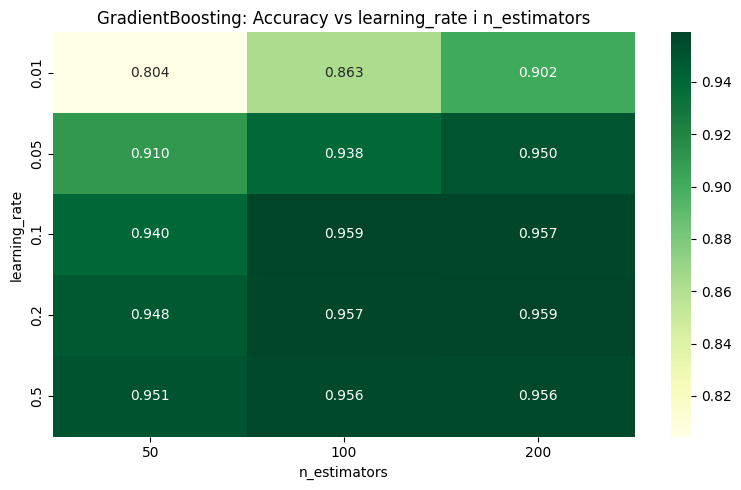


Najlepsza konfiguracja GB: n=100, lr=0.1, acc=0.9590


In [379]:
# GradientBoosting: trade-off n_estimators vs learning_rate

# Siatka parametrów
lr_values = [0.01, 0.05, 0.1, 0.2, 0.5]
n_values  = [50, 100, 200]

prep_gb = preprocessor_tree
prep_gb.fit(X_train)
X_tr_gb = prep_gb.transform(X_train)
X_te_gb = prep_gb.transform(X_test)

gb_results = []
for n in n_values:
    for lr_val in lr_values:
        m = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr_val,
            max_depth=3, random_state=42
        )
        m.fit(X_tr_gb, y_train)
        acc = accuracy_score(y_test, m.predict(X_te_gb))
        gb_results.append({"n_estimators": n, "learning_rate": lr_val, "accuracy": acc})

gb_df = pd.DataFrame(gb_results)
pivot  = gb_df.pivot(index="learning_rate", columns="n_estimators", values="accuracy")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", ax=ax)
ax.set_title("GradientBoosting: Accuracy vs learning_rate i n_estimators")
ax.set_xlabel("n_estimators")
ax.set_ylabel("learning_rate")
plt.tight_layout()
plt.show()

# Najlepsza konfiguracja
best_row = gb_df.loc[gb_df["accuracy"].idxmax()]
print(f"\nNajlepsza konfiguracja GB: n={int(best_row.n_estimators)}, "
      f"lr={best_row.learning_rate}, acc={best_row.accuracy:.4f}")

In [380]:
# GradientBoosting (najlepsza konfiguracja)
gb_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=3, random_state=42
    ))
])
gb_pipe = evaluate_model("GradientBoosting (n=200, lr=0.1, depth=3)",
                          gb_pipe, X_train, X_test, y_train, y_test)


  GradientBoosting (n=200, lr=0.1, depth=3)
  Accuracy       : 95.74%
  F1 macro       : 95.70%
  CV Acc         : 96.21% ± 0.96%
  Confidence     : 97.01%
  Inference time : 9.312 ms


### 6. Stacking i Voting

In [381]:
# Voting classifier

voting_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  VotingClassifier(
        estimators=[
            ("dt",  DecisionTreeClassifier(max_depth=8, random_state=42)),
            ("rf",  RandomForestClassifier(n_estimators=100, random_state=42)),
            ("lr",  LogisticRegression(max_iter=5000, random_state=42)),
        ],
        voting="soft"
    ))
])
voting_pipe = evaluate_model("VotingClassifier – soft (DT + RF + LR)",
                              voting_pipe, X_train, X_test, y_train, y_test)


  VotingClassifier – soft (DT + RF + LR)
  Accuracy       : 92.43%
  F1 macro       : 92.28%
  CV Acc         : 94.92% ± 1.66%
  Confidence     : 81.74%
  Inference time : 8.275 ms


In [382]:
# Stacking Classifier
stacking_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  StackingClassifier(
        estimators=[
            ("dt",   DecisionTreeClassifier(max_depth=6, random_state=42)),
            ("bag",  BaggingClassifier(
                         estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
                         n_estimators=30, random_state=42)),
            ("ada",  AdaBoostClassifier(
                         estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
                         n_estimators=50, random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5,
        passthrough=False,
    ))
])
stacking_pipe = evaluate_model("StackingClassifier (DT + Bagging + AdaBoost → LR)",
                                stacking_pipe, X_train, X_test, y_train, y_test)


  StackingClassifier (DT + Bagging + AdaBoost → LR)
  Accuracy       : 88.33%
  F1 macro       : 88.09%
  CV Acc         : 88.36% ± 1.77%
  Confidence     : 87.57%
  Inference time : 6.949 ms


### 7. Walidacja i porównanie modeli

In [383]:
# tabela wynikow
results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
results_df.index.name = "Model"
print("\n=== PORÓWNANIE WSZYSTKICH MODELI ===\n")
print(results_df.to_string())


=== PORÓWNANIE WSZYSTKICH MODELI ===

                                                       Accuracy  F1 macro  CV Acc (mean)  CV Acc (std)  Confidence  Inference (ms)
Model                                                                                                                             
GradientBoosting (n=200, lr=0.1, depth=3)                0.9574    0.9570         0.9621        0.0096      0.9701           9.312
Bagging – głębokie drzewo (depth=None, n=50)             0.9416    0.9417         0.9486        0.0139      0.9221           4.517
VotingClassifier – soft (DT + RF + LR)                   0.9243    0.9228         0.9492        0.0166      0.8174           8.275
AdaBoost – płytkie drzewo (n=100, lr=0.5)                0.9148    0.9150         0.9411        0.0148      0.1517          12.898
Drzewo decyzyjne (baseline)                              0.9006    0.8992         0.9343        0.0120      1.0000           1.860
StackingClassifier (DT + Bagging + AdaBoost 

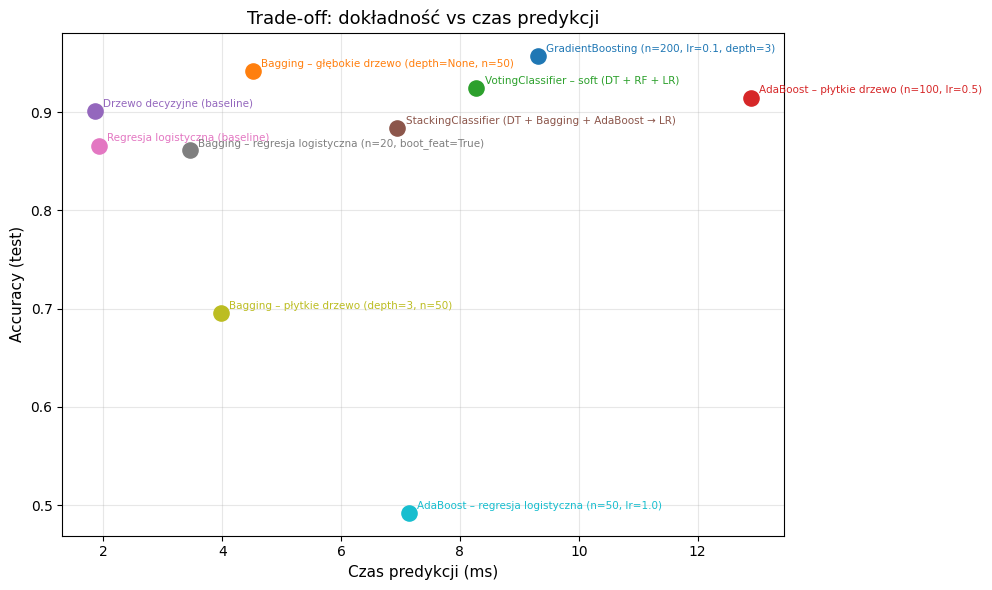

In [384]:
# Wykres: Accuracy vs Inference time
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))

for (model_name, row), color in zip(results_df.iterrows(), colors):
    ax.scatter(row["Inference (ms)"], row["Accuracy"],
               s=120, color=color, zorder=5)
    ax.annotate(model_name,
                xy=(row["Inference (ms)"], row["Accuracy"]),
                xytext=(6, 3), textcoords="offset points",
                fontsize=7.5, color=color)

ax.set_xlabel("Czas predykcji (ms)", fontsize=11)
ax.set_ylabel("Accuracy (test)", fontsize=11)
ax.set_title("Trade-off: dokładność vs czas predykcji", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

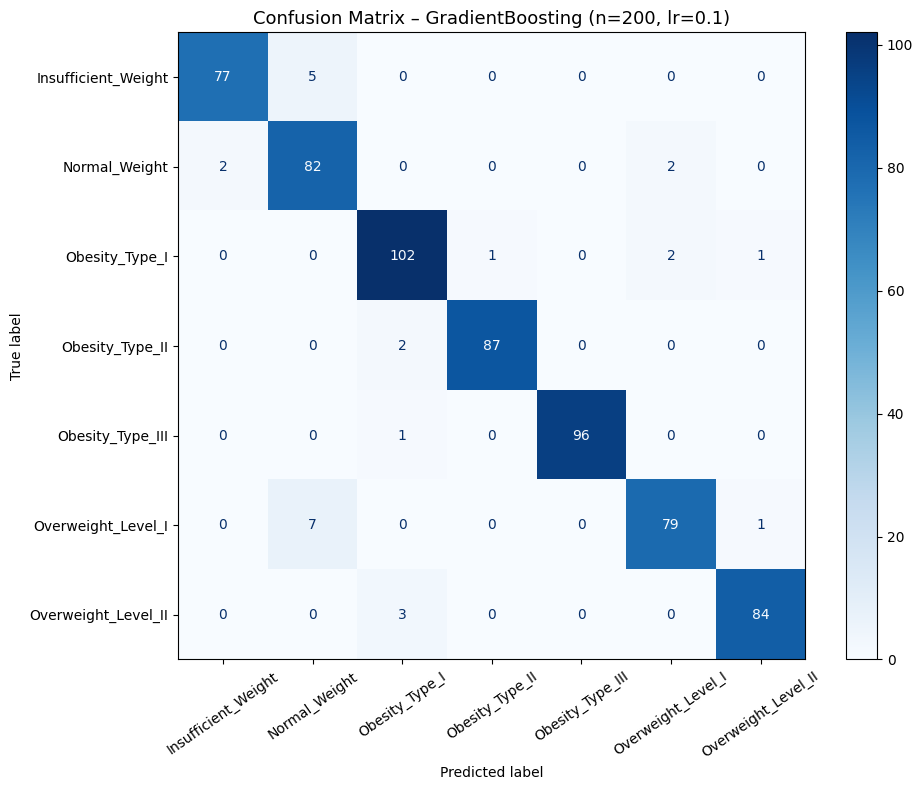

In [385]:
# Confusion matrix dla najlepszego modelu
# Zakładamy GradientBoosting jako kandydat do wdrożenia
best_pipe = gb_pipe

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    best_pipe, X_test, y_test,
    display_labels=best_pipe.classes_,
    cmap="Blues",
    xticks_rotation=35,
    ax=ax
)
ax.set_title("Confusion Matrix – GradientBoosting (n=200, lr=0.1)", fontsize=13)
plt.tight_layout()
plt.show()

In [386]:
# Classification report najlepszego modelu
y_pred_best = best_pipe.predict(X_test)
print("=== Classification Report – GradientBoosting ===\n")
print(classification_report(y_test, y_pred_best))

=== Classification Report – GradientBoosting ===

                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.94      0.96        82
      Normal_Weight       0.87      0.95      0.91        86
     Obesity_Type_I       0.94      0.96      0.95       106
    Obesity_Type_II       0.99      0.98      0.98        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.95      0.91      0.93        87
Overweight_Level_II       0.98      0.97      0.97        87

           accuracy                           0.96       634
          macro avg       0.96      0.96      0.96       634
       weighted avg       0.96      0.96      0.96       634



### 8. Wnioski

In [409]:
print("""
WNIOSKI do zadania 1
==========================================
      
=== PORÓWNANIE WSZYSTKICH MODELI ===

                                                       Accuracy  F1 macro  CV Acc (mean)  CV Acc (std)  Confidence  Inference (ms)
Model                                                                                                                             
GradientBoosting (n=200, lr=0.1, depth=3)                0.9574    0.9570         0.9621        0.0096      0.9701           9.312
Bagging – głębokie drzewo (depth=None, n=50)             0.9416    0.9417         0.9486        0.0139      0.9221           4.517
VotingClassifier – soft (DT + RF + LR)                   0.9243    0.9228         0.9492        0.0166      0.8174           8.275
AdaBoost – płytkie drzewo (n=100, lr=0.5)                0.9148    0.9150         0.9411        0.0148      0.1517          12.898
Drzewo decyzyjne (baseline)                              0.9006    0.8992         0.9343        0.0120      1.0000           1.860
StackingClassifier (DT + Bagging + AdaBoost → LR)        0.8833    0.8809         0.8836        0.0177      0.8757           6.949
Regresja logistyczna (baseline)                          0.8659    0.8622         0.8680        0.0129      0.7340           1.920
Bagging – regresja logistyczna (n=20, boot_feat=True)    0.8612    0.8559         0.8653        0.0125      0.6012           3.456
Bagging – płytkie drzewo (depth=3, n=50)                 0.6956    0.6734         0.7048        0.0515      0.6179           3.974
AdaBoost – regresja logistyczna (n=50, lr=1.0)           0.4921    0.4854         0.4828        0.0287      0.1474           7.138
      

1. REKOMENDACJA DO WDROŻENIA
    GradientBoosting (n=200, lr=0.1, max_depth=3)

    - Najwyższa accuracy (95.74%) i F1 macro (95.70%) spośród
      wszystkich testowanych modeli
    - Najwyższa pewność predykcji (97.01%) – lekarz może ocenić,
      kiedy model jest niepewny i skierować pacjenta na dalsze
      badania zamiast polegać wyłącznie na wyniku algorytmu
    - Stabilny (CV: 96.21% ± 0.96%) – niska wariancja oznacza,
      że model generalizuje dobrze na nowych pacjentach
    - Czas predykcji (9.1 ms) akceptowalny – model trenowany
      offline centralnie, eksportowany do przychodni jako plik


2. MODELE DO ODRZUCENIA / TYLKO REFERENCYJNE

    - AdaBoost z regresją logistyczną (49.21%): kompletna
      porażka – gorszy od losowego klasyfikatora dla 7 klas.
      LR jako model bazowy dla AdaBoost jest zbyt słaby dla
      tego nieliniowego problemu
    - Bagging z płytkimi drzewami (69.56%): zaskakująco słaby.
      Płytkie drzewa (max_depth=3) jako baza Baggingu są zbyt
      niedopasowane (high bias) – komitet wzmacnia błąd, nie
      wariancję. Bagging z głębokimi drzewami (94.16%) działa
      znacznie lepiej, co potwierdza tę diagnozę
    - StackingClassifier (88.33%): gorszy od drzewa bazowego
      (90.06%). Modele bazowe (DT, Bagging, AdaBoost) nie są
      wystarczająco zróżnicowane, by meta-klasyfikator mógł
      wyciągnąć dodatkową wartość
    - Drzewo decyzyjne i regresja logistyczna: użyteczne jako
      modele referencyjne i do interpretacji przez lekarza,
      ale dokładność (90.06% / 86.59%) niewystarczająca do
      wdrożenia krajowego


3. UWAGI PRAKTYCZNE

    - Accuracy nie jest jedynym wyznacznikiem – w kontekście
      medycznym kluczowy jest recall dla klas otyłości: lepiej
      zidentyfikować kogoś jako zagrożonego, niż przeoczyć przypadek
    - F1 macro zbliżone do Accuracy dla GB oznacza, że model radzi
      sobie równomiernie ze wszystkimi 7 klasami – brak faworyzowania
      klas najliczniejszych
    - AdaBoost z drzewem (91.48%) ma najdłuższy czas predykcji
      (12.1 ms) przy gorszym wyniku niż GB – niekorzystny trade-off
    - W przypadku placówek z ekstremalnie ograniczonymi zasobami sprzętowymi
      alternatywą jest Bagging z głębokimi drzewami (4.5 ms, 94.16%) –
      akceptowalny kompromis między szybkością a dokładnością.
""")


WNIOSKI do zadania 1

=== PORÓWNANIE WSZYSTKICH MODELI ===

                                                       Accuracy  F1 macro  CV Acc (mean)  CV Acc (std)  Confidence  Inference (ms)
Model                                                                                                                             
GradientBoosting (n=200, lr=0.1, depth=3)                0.9574    0.9570         0.9621        0.0096      0.9701           9.312
Bagging – głębokie drzewo (depth=None, n=50)             0.9416    0.9417         0.9486        0.0139      0.9221           4.517
VotingClassifier – soft (DT + RF + LR)                   0.9243    0.9228         0.9492        0.0166      0.8174           8.275
AdaBoost – płytkie drzewo (n=100, lr=0.5)                0.9148    0.9150         0.9411        0.0148      0.1517          12.898
Drzewo decyzyjne (baseline)                              0.9006    0.8992         0.9343        0.0120      1.0000           1.860
StackingClassifier (DT

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

### 0. importy

In [388]:
# pobranie danych
mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features
y = mushroom.data.targets.squeeze()

print("Kształt X:", X.shape)
print("Kształt y:", y.shape)
print("\nRozkład klas:")
print(y.value_counts())
print("\nPrzykładowe wiersze:")
X.head()

Kształt X: (8124, 22)
Kształt y: (8124,)

Rozkład klas:
poisonous
e    4208
p    3916
Name: count, dtype: int64

Przykładowe wiersze:


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


### 1. EDA - analiza

In [389]:
# przeglad danych
df = X.copy()
df["class"] = y

print("=== Informacje o zbiorze ===")
df.info()

print("\n=== Braki danych ===")
missing = X.isnull().sum()
print(missing[missing > 0])

=== Informacje o zbiorze ===
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   cap-shape                 8124 non-null   str  
 1   cap-surface               8124 non-null   str  
 2   cap-color                 8124 non-null   str  
 3   bruises                   8124 non-null   str  
 4   odor                      8124 non-null   str  
 5   gill-attachment           8124 non-null   str  
 6   gill-spacing              8124 non-null   str  
 7   gill-size                 8124 non-null   str  
 8   gill-color                8124 non-null   str  
 9   stalk-shape               8124 non-null   str  
 10  stalk-root                5644 non-null   str  
 11  stalk-surface-above-ring  8124 non-null   str  
 12  stalk-surface-below-ring  8124 non-null   str  
 13  stalk-color-above-ring    8124 non-null   str  
 14  stalk-color-below-ring

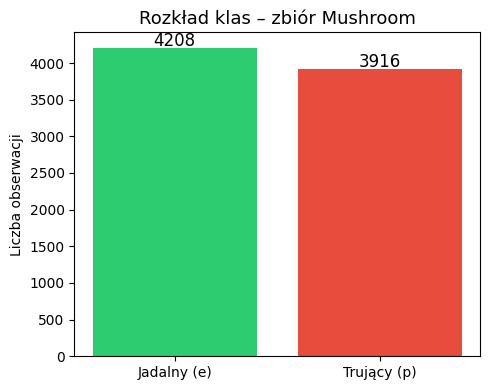

In [390]:
# rozklad klas
fig, ax = plt.subplots(figsize=(5, 4))
counts = y.value_counts()
bars = ax.bar(["Jadalny (e)", "Trujący (p)"],
              [counts["e"], counts["p"]],
              color=["#2ecc71", "#e74c3c"])
for bar, val in zip(bars, [counts["e"], counts["p"]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha="center", fontsize=12)
ax.set_title("Rozkład klas – zbiór Mushroom", fontsize=13)
ax.set_ylabel("Liczba obserwacji")
plt.tight_layout()
plt.show()

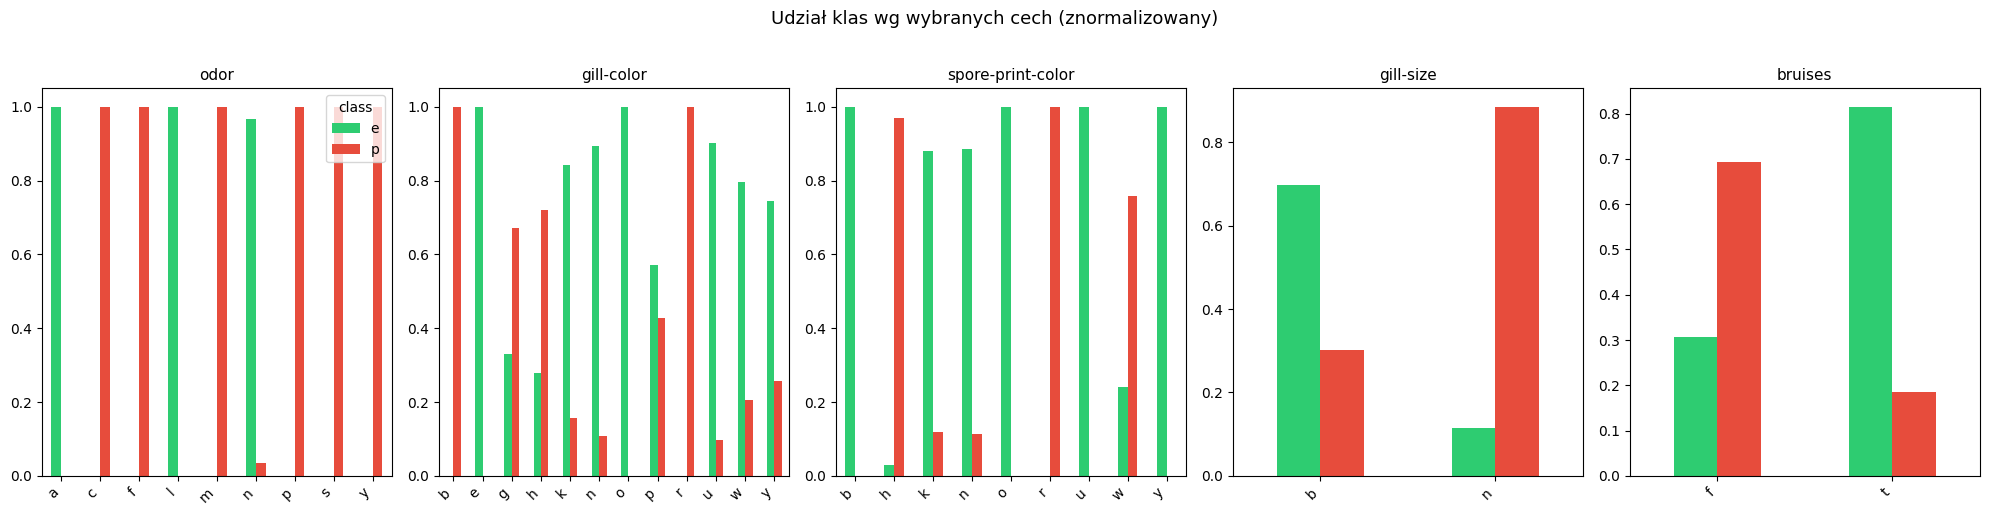

In [391]:
# cechy kategoryczne
key_cols = ["odor", "gill-color", "spore-print-color", "gill-size", "bruises"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, key_cols):
    ct = pd.crosstab(df[col], df["class"], normalize="index")
    ct.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"],
            legend=(col == key_cols[0]))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.suptitle("Udział klas wg wybranych cech (znormalizowany)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

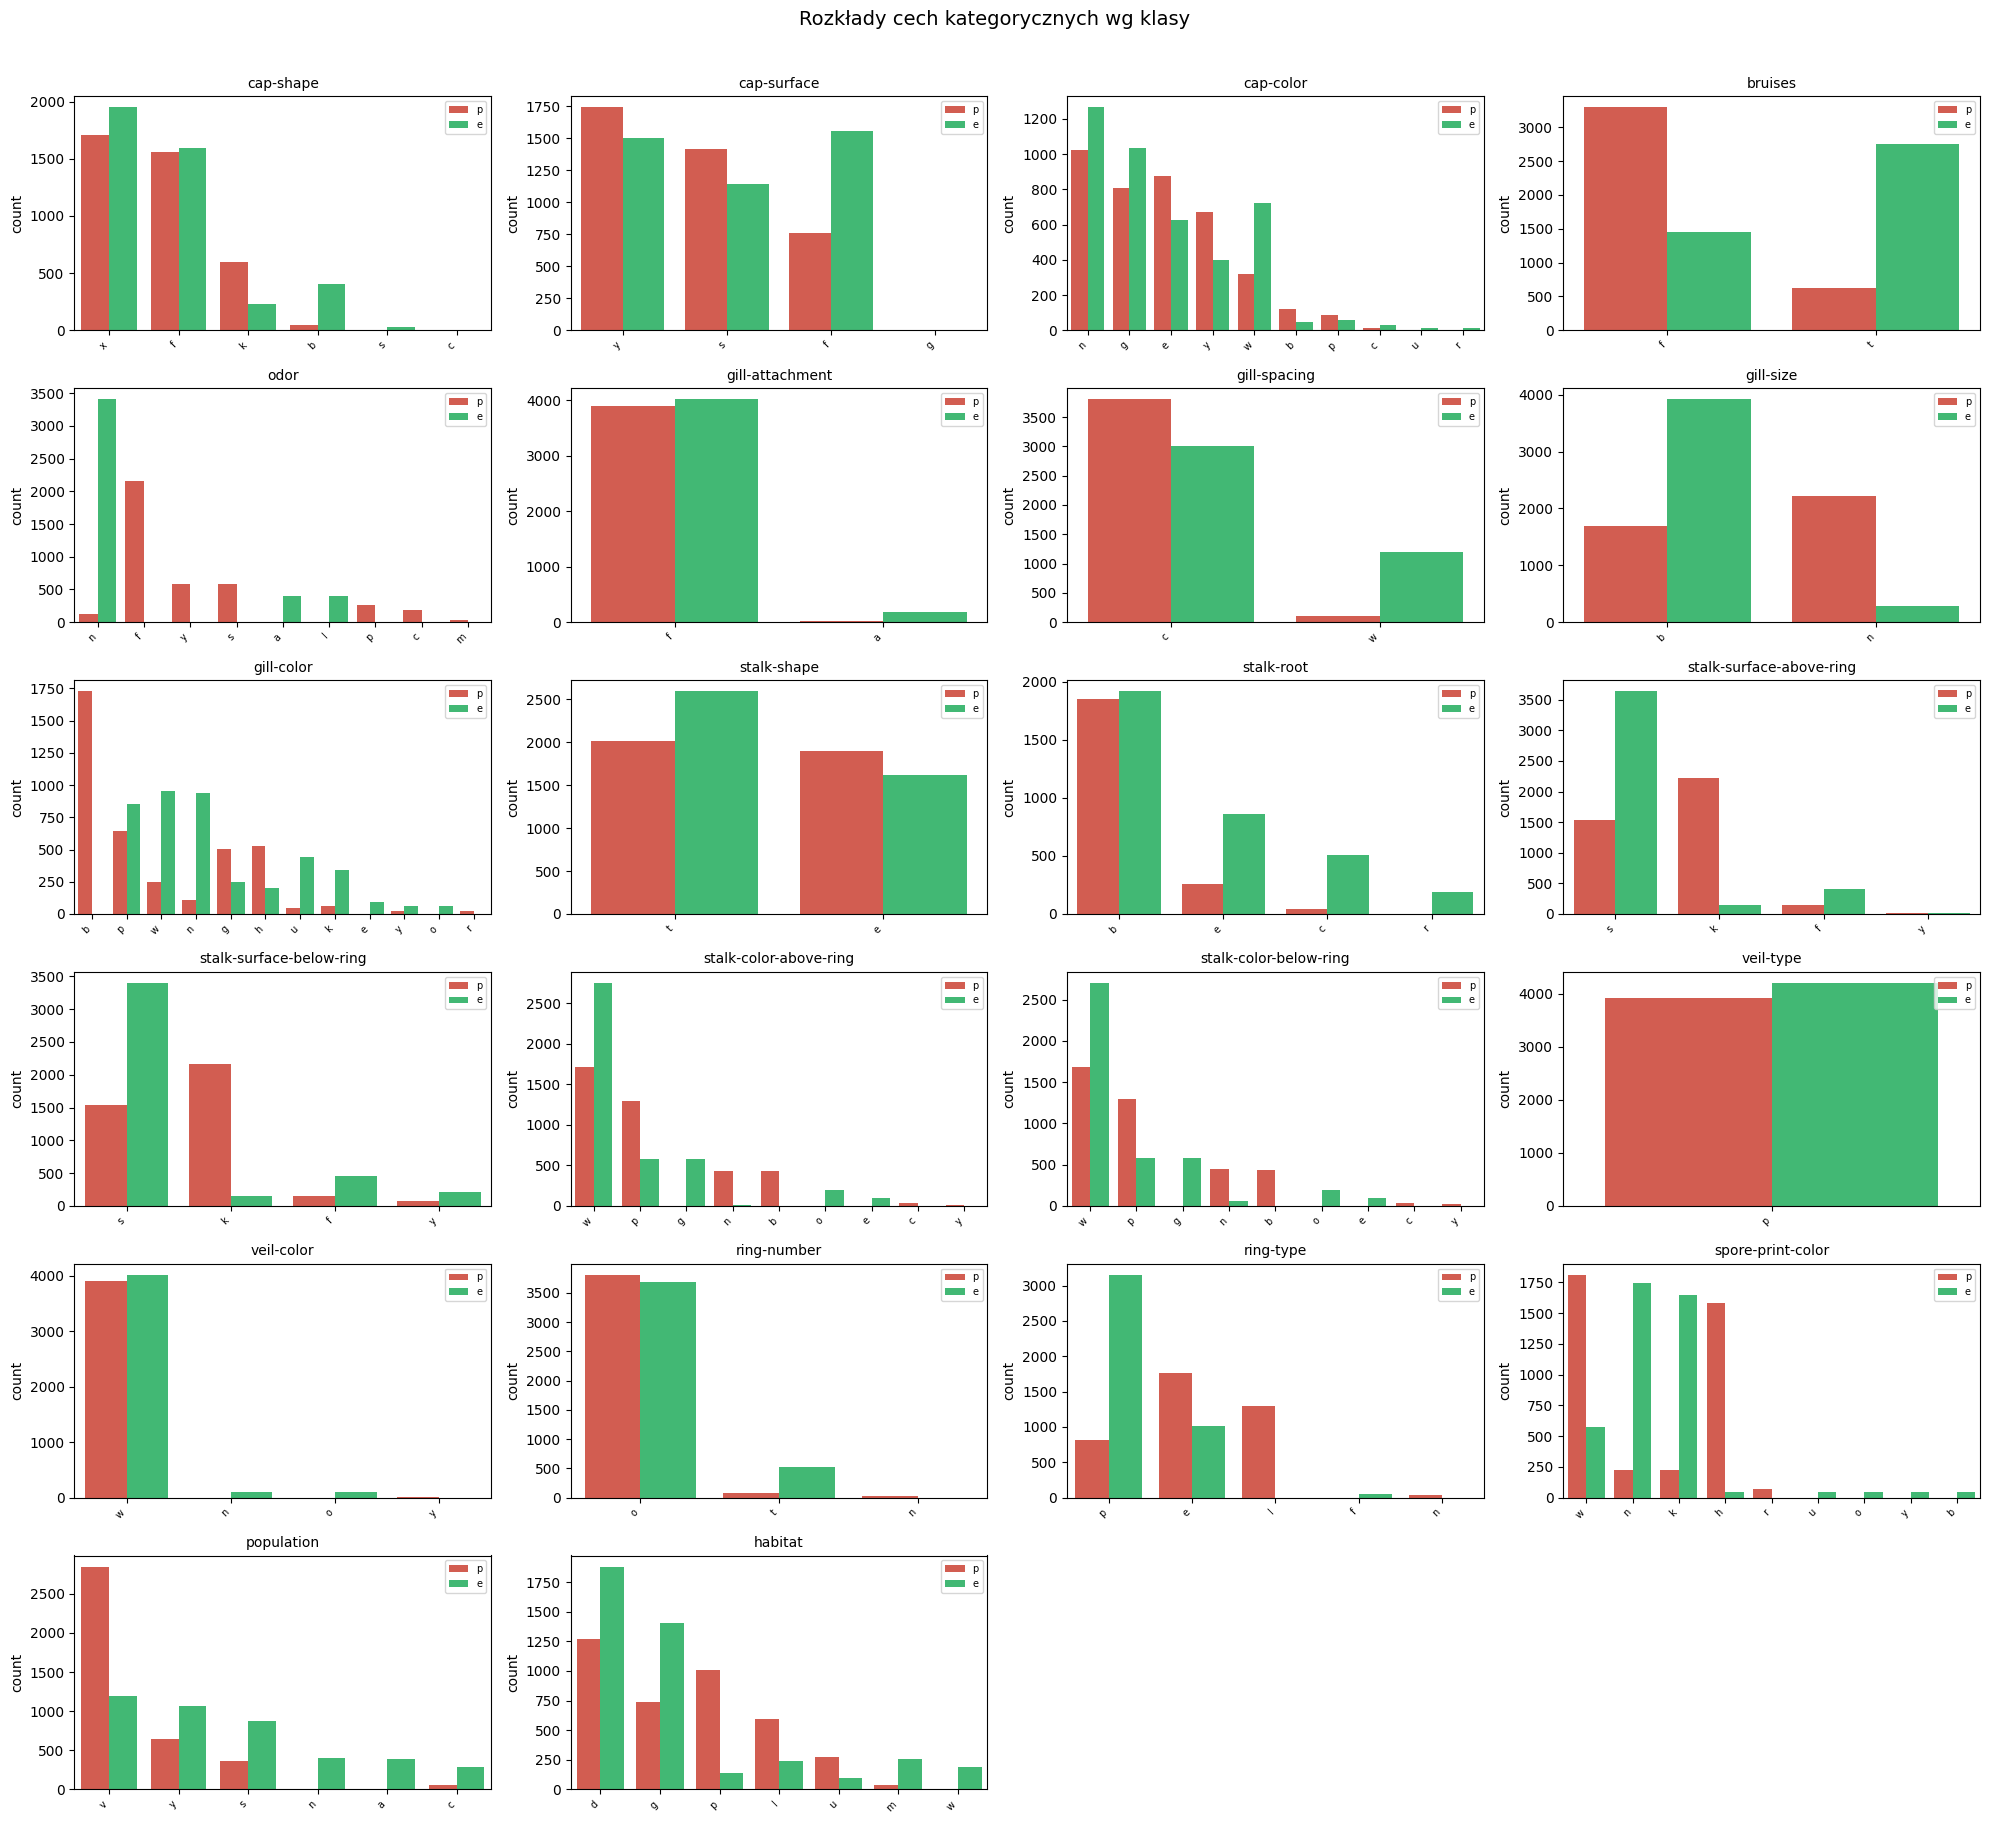

In [392]:
# rozklady wszystkich cech
cat_cols = X.columns.tolist()

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="class",
                  order=order, ax=ax,
                  palette={"e": "#2ecc71", "p": "#e74c3c"})
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=7)

# Ukryj puste wykresy
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle("Rozkłady cech kategorycznych wg klasy", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2. Preprocessing i podzial danych

In [393]:
# Uzupełnienie braków w stalk-root osobną kategorią
X_clean = X.copy()
X_clean["stalk-root"] = X_clean["stalk-root"].fillna("missing")

# Enkodowanie etykiet (e=0, p=1) – p to klasa pozytywna (trujący)
le = LabelEncoder()
y_enc = le.fit_transform(y)  # e->0, p->1
print("Mapowanie klas:", dict(zip(le.classes_, le.transform(le.classes_))))

# Wszystkie cechy są kategoryczne – OrdinalEncoder
all_cols = X_clean.columns.tolist()

preprocessor_tree = ColumnTransformer(transformers=[
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), all_cols)
], remainder="drop")

preprocessor_lr = ColumnTransformer(transformers=[
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), all_cols)
], remainder="drop")
# Dla LR dodajemy StandardScaler po OrdinalEncoderze w Pipeline

# Podział
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_enc, test_size=0.3, stratify=y_enc, random_state=42
)

print(f"\nZbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek")
print(f"Trujące w teście: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Mapowanie klas: {'e': np.int64(0), 'p': np.int64(1)}

Zbiór treningowy: 5686 próbek
Zbiór testowy:    2438 próbek
Trujące w teście: 1175 (48.2%)


In [394]:
results2 = {}

def evaluate_model2(name, pipeline, X_train, X_test, y_train, y_test, cv=5):
    """Trenuje pipeline, mierzy acc, recall dla klasy p, F1, czas, confidence."""
    pipeline.fit(X_train, y_train)

    # Czas predykcji
    times = []
    for _ in range(50):
        t0 = time.perf_counter()
        pipeline.predict(X_test)
        times.append(time.perf_counter() - t0)
    inference_ms = np.mean(times) * 1000

    y_pred = pipeline.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # recall dla klasy p (trujący=1)

    if hasattr(pipeline, "predict_proba"):
        proba      = pipeline.predict_proba(X_test)
        confidence = float(np.mean(np.max(proba, axis=1)))
    else:
        confidence = float("nan")

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")

    results2[name] = {
        "Accuracy":         round(acc, 4),
        "Recall (trujący)": round(recall, 4),
        "F1":               round(f1, 4),
        "CV Acc (mean)":    round(cv_scores.mean(), 4),
        "CV Acc (std)":     round(cv_scores.std(), 4),
        "Confidence":       round(confidence, 4),
        "Inference (ms)":   round(inference_ms, 3),
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy         : {acc*100:.2f}%")
    print(f"  Recall (trujący) : {recall*100:.2f}%")
    print(f"  F1               : {f1*100:.2f}%")
    print(f"  CV Acc           : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"  Confidence       : {confidence*100:.2f}%")
    print(f"  Inference time   : {inference_ms:.3f} ms")

    return pipeline

### 3. Modele bazowe

In [395]:
# 1. Drzewo decyzyjne
dt_pipe2 = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  DecisionTreeClassifier(random_state=42))
])
dt_pipe2 = evaluate_model2("Drzewo decyzyjne (baseline)", dt_pipe2,
                             X_train, X_test, y_train, y_test)

# 2. Regresja logistyczna
lr_pipe2 = Pipeline([
    ("prep", preprocessor_lr),
    ("scaler", StandardScaler()),
    ("clf",  LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe2 = evaluate_model2("Regresja logistyczna (baseline)", lr_pipe2,
                             X_train, X_test, y_train, y_test)


  Drzewo decyzyjne (baseline)
  Accuracy         : 100.00%
  Recall (trujący) : 100.00%
  F1               : 100.00%
  CV Acc           : 100.00% ± 0.00%
  Confidence       : 100.00%
  Inference time   : 3.927 ms

  Regresja logistyczna (baseline)
  Accuracy         : 96.43%
  Recall (trujący) : 96.51%
  F1               : 96.31%
  CV Acc           : 96.08% ± 0.76%
  Confidence       : 94.88%
  Inference time   : 3.999 ms


Drzewo (depth=4) Accuracy: 98.28%
Recall (trujący):          99.15%


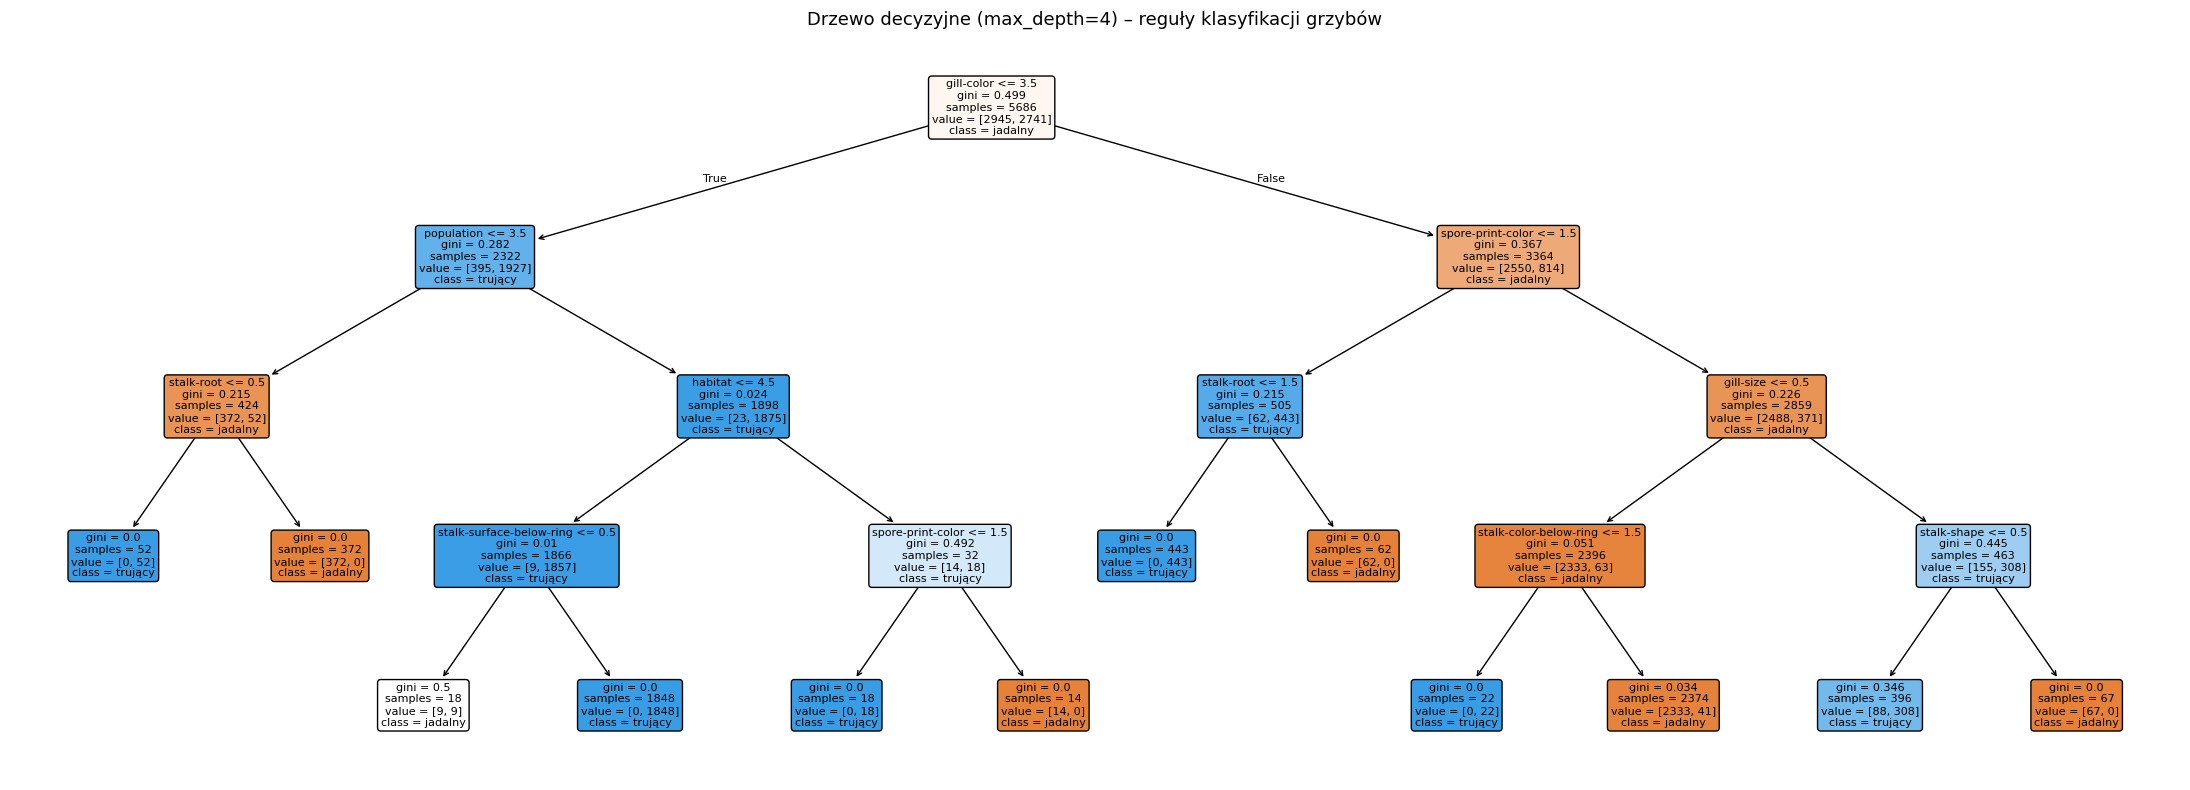

In [396]:
# Płytkie drzewo – do wizualizacji i interpretacji przez lekarza/grzybiarza
dt_shallow = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  DecisionTreeClassifier(max_depth=4, random_state=42))
])
dt_shallow.fit(X_train, y_train)
y_pred_sh = dt_shallow.predict(X_test)
print(f"Drzewo (depth=4) Accuracy: {accuracy_score(y_test, y_pred_sh)*100:.2f}%")
print(f"Recall (trujący):          {recall_score(y_test, y_pred_sh)*100:.2f}%")

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_shallow.named_steps["clf"],
    feature_names=all_cols,
    class_names=["jadalny", "trujący"],
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title("Drzewo decyzyjne (max_depth=4) – reguły klasyfikacji grzybów", fontsize=13)
plt.tight_layout()
plt.show()

### 4. Modele zespołowe (Ensemble)

In [397]:
# Ensemble: RandomForest
rf_pipe2 = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipe2 = evaluate_model2("RandomForest (n=100)", rf_pipe2,
                             X_train, X_test, y_train, y_test)


  RandomForest (n=100)
  Accuracy         : 100.00%
  Recall (trujący) : 100.00%
  F1               : 100.00%
  CV Acc           : 100.00% ± 0.00%
  Confidence       : 99.96%
  Inference time   : 11.453 ms


In [398]:
#  Ensemble: Bagging
bag_pipe2 = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=50, bootstrap=True, random_state=42
    ))
])
bag_pipe2 = evaluate_model2("Bagging – głębokie drzewo (n=50)", bag_pipe2,
                              X_train, X_test, y_train, y_test)


  Bagging – głębokie drzewo (n=50)
  Accuracy         : 100.00%
  Recall (trujący) : 100.00%
  F1               : 100.00%
  CV Acc           : 100.00% ± 0.00%
  Confidence       : 99.99%
  Inference time   : 8.511 ms


In [399]:
# Ensemble: GradientBoosting
gb_pipe2 = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=3, random_state=42
    ))
])
gb_pipe2 = evaluate_model2("GradientBoosting (n=100, lr=0.1)", gb_pipe2,
                             X_train, X_test, y_train, y_test)


  GradientBoosting (n=100, lr=0.1)
  Accuracy         : 100.00%
  Recall (trujący) : 100.00%
  F1               : 100.00%
  CV Acc           : 100.00% ± 0.00%
  Confidence       : 99.70%
  Inference time   : 5.632 ms


In [400]:
# Ensemble: Voting
voting_pipe2 = Pipeline([
    ("prep", preprocessor_tree),
    ("clf",  VotingClassifier(
        estimators=[
            ("dt",  DecisionTreeClassifier(max_depth=8, random_state=42)),
            ("rf",  RandomForestClassifier(n_estimators=50, random_state=42)),
            ("gb",  GradientBoostingClassifier(n_estimators=50, random_state=42)),
        ],
        voting="soft"
    ))
])
voting_pipe2 = evaluate_model2("VotingClassifier – soft (DT + RF + GB)", voting_pipe2,
                                X_train, X_test, y_train, y_test)


  VotingClassifier – soft (DT + RF + GB)
  Accuracy         : 100.00%
  Recall (trujący) : 100.00%
  F1               : 100.00%
  CV Acc           : 100.00% ± 0.00%
  Confidence       : 99.47%
  Inference time   : 9.122 ms


### 5. Walidacja i porównanie modeli

In [401]:
# porownanie modeli
results2_df = pd.DataFrame(results2).T.sort_values("Recall (trujący)", ascending=False)
results2_df.index.name = "Model"
print("\n=== PORÓWNANIE WSZYSTKICH MODELI – MUSHROOM ===\n")
print(results2_df.to_string())


=== PORÓWNANIE WSZYSTKICH MODELI – MUSHROOM ===

                                        Accuracy  Recall (trujący)      F1  CV Acc (mean)  CV Acc (std)  Confidence  Inference (ms)
Model                                                                                                                              
Drzewo decyzyjne (baseline)               1.0000            1.0000  1.0000         1.0000        0.0000      1.0000           3.927
RandomForest (n=100)                      1.0000            1.0000  1.0000         1.0000        0.0000      0.9996          11.453
Bagging – głębokie drzewo (n=50)          1.0000            1.0000  1.0000         1.0000        0.0000      0.9999           8.511
GradientBoosting (n=100, lr=0.1)          1.0000            1.0000  1.0000         1.0000        0.0000      0.9970           5.632
VotingClassifier – soft (DT + RF + GB)    1.0000            1.0000  1.0000         1.0000        0.0000      0.9947           9.122
Regresja logistyczna (base

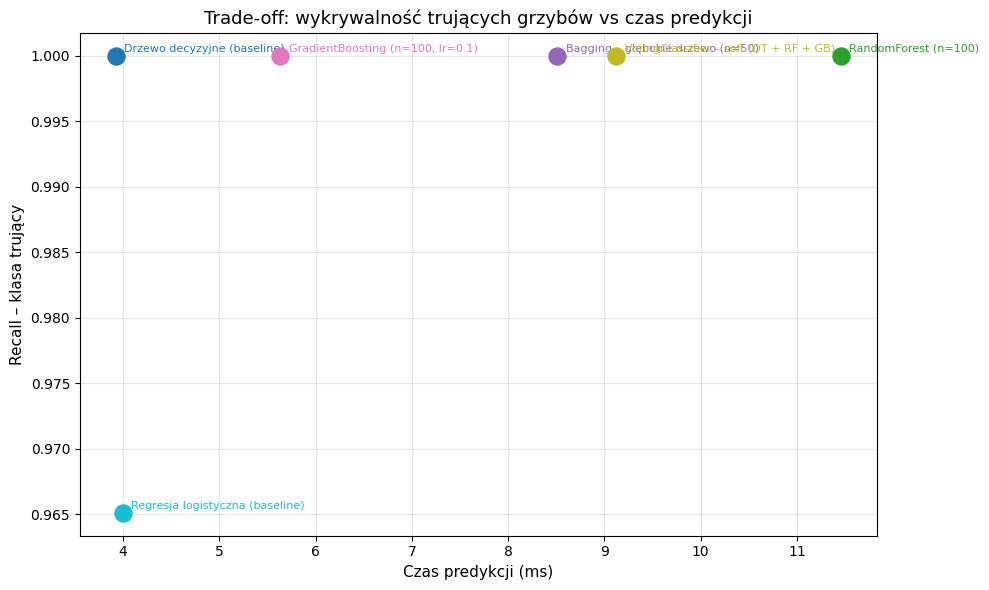

In [402]:
# Wykres: Recall vs Inference time
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results2_df)))

for (model_name, row), color in zip(results2_df.iterrows(), colors):
    ax.scatter(row["Inference (ms)"], row["Recall (trujący)"],
               s=150, color=color, zorder=5)
    ax.annotate(model_name,
                xy=(row["Inference (ms)"], row["Recall (trujący)"]),
                xytext=(6, 3), textcoords="offset points",
                fontsize=8, color=color)

ax.set_xlabel("Czas predykcji (ms)", fontsize=11)
ax.set_ylabel("Recall – klasa trujący", fontsize=11)
ax.set_title("Trade-off: wykrywalność trujących grzybów vs czas predykcji", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

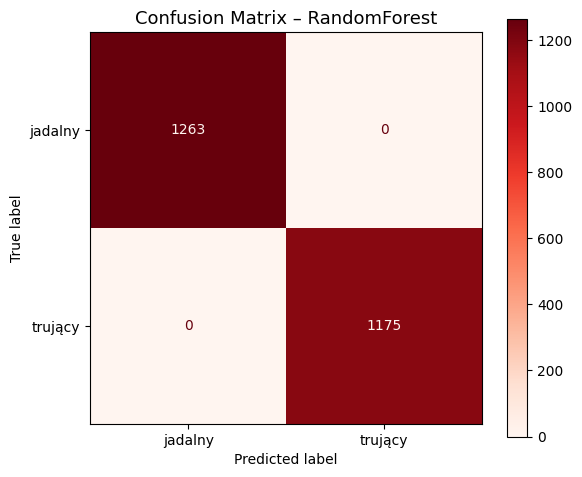


=== Classification Report ===

              precision    recall  f1-score   support

     jadalny       1.00      1.00      1.00      1263
     trujący       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [403]:
# Confusion matrix najlepszego modelu
best_pipe2 = dt_pipe2

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_pipe2, X_test, y_test,
    display_labels=["jadalny", "trujący"],
    cmap="Reds", ax=ax
)
ax.set_title("Confusion Matrix – RandomForest", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Classification Report ===\n")
print(classification_report(y_test, best_pipe2.predict(X_test),
                             target_names=["jadalny", "trujący"]))

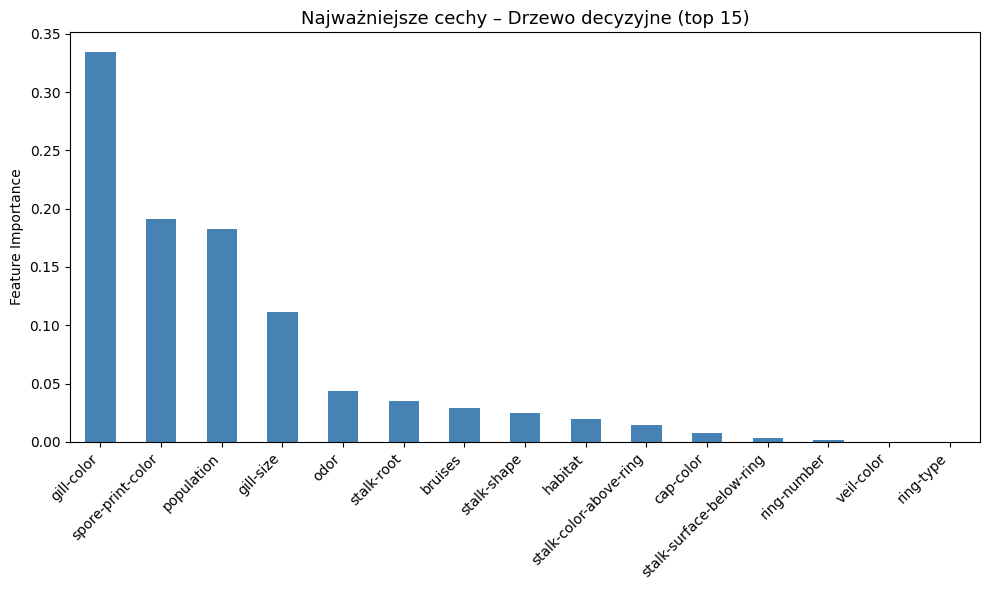

In [ ]:
# Ważność cech (RandomForest)
feat_names = all_cols

importances = dt_pipe2.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Najważniejsze cechy – Drzewo decyzyjne (top 15)", fontsize=13)
ax.set_ylabel("Feature Importance")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6. Wnioski

In [408]:
print("""
WNIOSKI – GRZYBOBRANIE
======================
      
=== PORÓWNANIE WSZYSTKICH MODELI – MUSHROOM ===

                                        Accuracy  Recall (trujący)      F1  CV Acc (mean)  CV Acc (std)  Confidence  Inference (ms)
Model                                                                                                                              
Drzewo decyzyjne (baseline)               1.0000            1.0000  1.0000         1.0000        0.0000      1.0000           3.927
RandomForest (n=100)                      1.0000            1.0000  1.0000         1.0000        0.0000      0.9996          11.453
Bagging – głębokie drzewo (n=50)          1.0000            1.0000  1.0000         1.0000        0.0000      0.9999           8.511
GradientBoosting (n=100, lr=0.1)          1.0000            1.0000  1.0000         1.0000        0.0000      0.9970           5.632
VotingClassifier – soft (DT + RF + GB)    1.0000            1.0000  1.0000         1.0000        0.0000      0.9947           9.122
Regresja logistyczna (baseline)           0.9643            0.9651  0.9631         0.9608        0.0076      0.9488           3.999

1. REKOMENDACJA DO WDROŻENIA
      
    Wszystkie modele drzew osiągnęły
    100% accuracy i 100% recall 
    dla klasy trujący – zbiór Mushroom jest deterministyczny,
    a cechy fizyczne grzyba jednoznacznie go opisują. 
    Przy remisie dokładności kryterium wyboru staje się czas predykcji.

    Rekomendowany model: Drzewo decyzyjne (baseline)
    - Najkrótszy czas predykcji (4 ms) – kluczowe przy niskiej baterii telefonu w warunkach terenowych
    - Recall = 100% – żaden trujący grzyb nie zostaje pominięty
    - W pełni interpretowalny – reguły decyzyjne można prześledzić
      krok po kroku na wykresie (komórka 10), co pozwala zrozumieć
      i zweryfikować każdą decyzję modelu
    - Najprostszy model okazał się jednocześnie najszybszy,
      najdokładniejszy i najłatwiejszy do zrozumienia


2. INTERPRETOWALNOŚĆ

    Drzewo decyzyjne z max_depth=4 pozwala prześledzić dokładnie,
    które cechy grzyba prowadzą do klasyfikacji jako trujący.
    Kilka pytań o zapach i kolor zarodników wystarcza do podjęcia decyzji
    Modele zespołowe (RF, GB, Voting) są czarnymi skrzynkami –
    nie można zrozumieć dlaczego model podjął daną decyzję,
    co w kontekście bezpieczeństwa jest poważną wadą.


3. MODELE DO ODRZUCENIA

    - RandomForest (11 ms): ponad 2x wolniejszy od drzewa
      przy identycznej dokładności – zbędny koszt obliczeniowy
    - Bagging (8 ms), Voting (9 ms): podobna sytuacja –
      większa złożoność bez żadnego zysku w dokładności
    - GradientBoosting: interpretowalność bliska zeru,
      czas gorszy niż drzewo – nic nie uzasadnia jego wyboru
    - Regresja logistyczna (96.4% recall): jedyny model który
      odpada merytorycznie – każdy pominięty trujący grzyb
      oznacza zatrucie, wynik poniżej 100% jest nieakceptowalny


4. UWAGI PRAKTYCZNE

    - Najsilniejszymi predyktorami okazały się:
      gill-color (kolor blaszek, 33%), 
      spore-print-color (kolor zarodników, 19%)
      i population (sposób wzrostu, 18%) 
    - w innych wychodzil zazwyczaj zapach (odor) CIEKAWOSTKA
    - Model mozna trenować offline i eksportować jako plik –
      predykcja w terenie jest natychmiastowa
    - Przy jakichkolwiek wątpliwościach (niska confidence)
      należy uznać grzyb za trujący – zasada ostrożności
    - zbior byl dosyc prosty wiec najprostszy model wygrywa
      we wszystkich kategoriach jednocześnie
""")


WNIOSKI – GRZYBOBRANIE

=== PORÓWNANIE WSZYSTKICH MODELI – MUSHROOM ===

                                        Accuracy  Recall (trujący)      F1  CV Acc (mean)  CV Acc (std)  Confidence  Inference (ms)
Model                                                                                                                              
Drzewo decyzyjne (baseline)               1.0000            1.0000  1.0000         1.0000        0.0000      1.0000           3.927
RandomForest (n=100)                      1.0000            1.0000  1.0000         1.0000        0.0000      0.9996          11.453
Bagging – głębokie drzewo (n=50)          1.0000            1.0000  1.0000         1.0000        0.0000      0.9999           8.511
GradientBoosting (n=100, lr=0.1)          1.0000            1.0000  1.0000         1.0000        0.0000      0.9970           5.632
VotingClassifier – soft (DT + RF + GB)    1.0000            1.0000  1.0000         1.0000        0.0000      0.9947           9.122
Re